# Neural additive model zoo

NAMpy separates **architecture** from **task**. An architecture determines
how feature and interaction functions are represented; regressor,
classifier, and LSS wrappers determine targets, losses, metrics, and
output transforms. This notebook explains every registered architecture
and uses a common small regression problem to make their inductive biases
comparable. The next notebook systematically executes all task variants.


## 1. Common neural additive workflow

Neural additive models learn $\eta=\beta_0+\sum_t f_t(x_t)$ by gradient
optimization or an architecture-specific solver. PreTab transforms
numerical and categorical inputs while retaining source-feature groups.
Early stopping monitors validation loss; learning-rate schedules change
the optimization trajectory; checkpoint averaging averages recent model
states. Sample weights alter the empirical loss.

Centered components shift each term to have zero reference mean and move
that shift into the intercept. Predictions remain unchanged. Explicit
interactions should be chosen from domain knowledge or a discovery
procedure evaluated separately from final fitting.


In [1]:
from pathlib import Path
import tempfile
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

FAST_MODE = True
N_SAMPLES = 160 if FAST_MODE else 5000
MAX_EPOCHS = 2 if FAST_MODE else 150
MAX_STEPS = 2 if FAST_MODE else -1
RANDOM_STATE = 7
CHECKPOINT_ROOT = Path(tempfile.mkdtemp(prefix="nampy-notebook-"))

NEURAL_FIT_KWARGS = {
    "max_epochs": MAX_EPOCHS,
    "max_steps": MAX_STEPS,
    "batch_size": 64 if FAST_MODE else 256,
    "random_state": RANDOM_STATE,
    "checkpoint_path": CHECKPOINT_ROOT,
    "logger": False,
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "num_sanity_val_steps": 0,
}

rng = np.random.default_rng(RANDOM_STATE)

n = N_SAMPLES
x1 = rng.uniform(-1.0, 1.0, n)
x2 = rng.normal(size=n)
group = pd.Categorical(rng.choice(["a", "b", "c"], size=n))
X = pd.DataFrame({"x1": x1, "x2": x2, "group": group})
y = np.sin(np.pi * x1) + 0.35 * x2**2 + 0.45 * x1 * x2 + 0.25 * (group == "b") + rng.normal(0, 0.15, n)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

from nampy import models

NEURAL_FIT_KWARGS["fast_dev_run"] = FAST_MODE

ARCH_KWARGS = {
    "linreg": {},
    "nam": {"layer_sizes": [12], "dropout": 0.0, "interactions": [("x1", "x2")]},
    "sian": {"layer_sizes": [12], "interactions": [("x1", "x2")]},
    "snam": {"layer_sizes": [12], "dropout": 0.0, "group_lasso_lambda": 0.01},
    "gpnam": {"rff_num_feat": 12, "interactions": [("x1", "x2")]},
    "igann": {"n_hid": 6, "n_estimators": 4, "early_stopping": 2},
    "nbm": {"layer_sizes": [12], "num_bases": 6, "nary": [1, 2], "dropout": 0.0, "bases_dropout": 0.0},
    "nbm_spam": {"layer_sizes": [12], "num_bases": 6, "ranks": [6], "batch_norm": False},
    "spam": {"ranks": [6], "dropout": 0.0},
    "natt": {"d_model": 8, "n_layers": 1, "n_heads": 2, "transformer_dim_feedforward": 16, "head_layer_sizes": (), "attn_dropout": 0.0},
    "namformer": {"d_model": 8, "n_layers": 1, "n_heads": 2, "transformer_dim_feedforward": 16, "head_layer_sizes": (), "attn_dropout": 0.0},
    "treenam": {"tree_depth": 2, "tree_lamda": 0.01},
    "ensemble_treenam": {"tree_depth": 2, "tree_lamda": 0.01, "num_estimators": 2},
    "nodegam": {"num_trees": 4, "num_layers": 1, "depth": 2, "anneal_steps": 10, "interaction_degree": 1},
    "qnam": {"layer_sizes": [12], "dropout": 0.0, "distributional_kwargs": {"quantiles": [0.1, 0.5, 0.9]}},
    "spline_nam": {"n_knots": 6, "smoothing": 0.01, "interactions": [("x1", "x2")]},
}

fitted_gallery = {}
comparison_rows = []

def parameter_count(estimator):
    module = getattr(getattr(estimator, "model", None), "model", None)
    return None if module is None else sum(p.numel() for p in module.parameters())

def reconstruct_components(components):
    link = np.asarray(components.link)
    def aligned(value):
        array = np.asarray(value, dtype=float)
        if link.ndim == 1 and array.shape == (link.shape[0], 1):
            return array[:, 0]
        if link.ndim == 2 and array.shape == (link.shape[0],):
            return array[:, None]
        return array
    reconstruction = aligned(components.intercept)
    for contribution in components.terms.values():
        reconstruction = reconstruction + aligned(contribution)
    if components.offset is not None:
        reconstruction = reconstruction + aligned(components.offset)
    return reconstruction

def fit_and_evaluate(name, estimator, target=y_train):
    started = time.perf_counter()
    estimator.fit(X_train, target, **NEURAL_FIT_KWARGS)
    elapsed = time.perf_counter() - started
    components = estimator.predict_components(X_test, center=True)
    reconstruction = reconstruct_components(components)
    error = float(np.max(np.abs(reconstruction - components.link)))
    try:
        components.validate_additive_reconstruction(rtol=1e-5, atol=1e-5)
        reconstruction_valid = True
    except ValueError:
        reconstruction_valid = False
    row = {
        "model": name,
        "test score": estimator.score(X_test, y_test) if "QNAM" not in name else estimator.score(X_test, y_test),
        "fit seconds": elapsed,
        "terms": len(components.terms),
        "interactions": len(estimator.interaction_importance(X_test, center=True)),
        "parameters": parameter_count(estimator),
        "reconstruction error": error,
        "reconstruction valid": reconstruction_valid,
    }
    fitted_gallery[name] = estimator
    comparison_rows.append(row)
    return row

def architecture_summary(estimator):
    return {
        "class": type(estimator).__name__,
        "architecture": estimator.architecture_name,
        "parameters": parameter_count(estimator),
        "features": estimator.feature_names_in_.tolist(),
    }


### 1.1 Preprocessing, training, and explanation with NAM

Min-max scaling maps numerical columns to a bounded range. PLE creates
piecewise-linear encodings with several transformed columns per source
feature. One-hot encoding keeps a categorical source feature grouped even
though it expands into multiple columns. Scaling and encoding are fitted
on training data only.


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


`Trainer.fit` stopped: `max_steps=1` reached.


{'class': 'NAMRegressor',
 'architecture': 'nam',
 'parameters': 1517,
 'features': ['x1', 'x2', 'group']}

,term,term_type,output,importance
0,group,main,0,0.030250
1,x1:x2,interaction,0,0.016165
2,x1,main,0,0.011576
3,x2,main,0,0.002335


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.985,NaN,0.014795,3,0.011576
1,x1,main,0,-0.956,NaN,0.014517,2,0.011576
2,x1,main,0,-0.897,NaN,0.014140,2,0.011576
3,x1,main,0,-0.791,NaN,0.012984,2,0.011576
4,x1,main,0,-0.6715,NaN,0.011957,2,0.011576
5,x1,main,0,-0.57,NaN,0.010272,2,0.011576
6,x1,main,0,-0.491,NaN,0.008328,3,0.011576
7,x1,main,0,-0.3745,NaN,0.006099,2,0.011576
8,x1,main,0,-0.216,NaN,0.005141,2,0.011576
9,x1,main,0,-0.0306,NaN,0.004272,2,0.011576


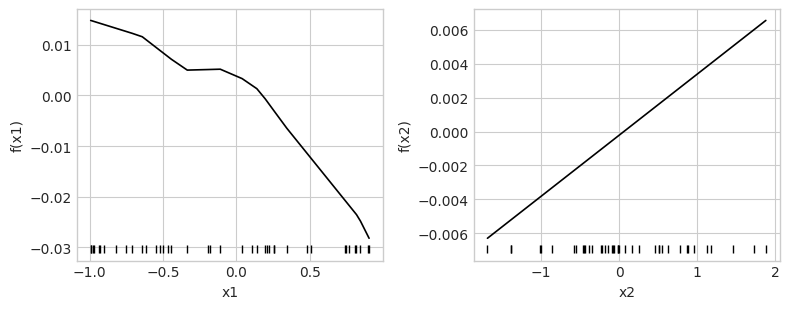

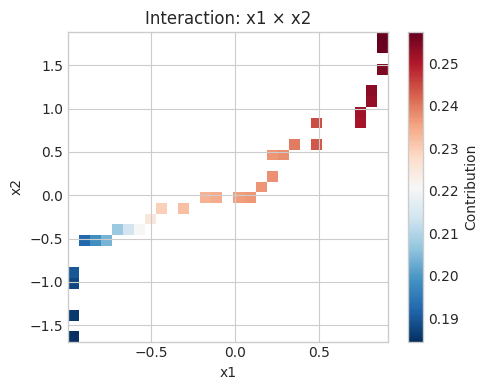

In [2]:
from nampy.models import NAMRegressor

nam = NAMRegressor(
    layer_sizes=[24, 12], dropout=0.0,
    numerical_preprocessing="minmax",
    categorical_preprocessing="one-hot",
    interactions=[("x1", "x2")],
)
fit_and_evaluate("NAM", nam)

components = nam.predict_components(X_test, center=True)
display(architecture_summary(nam))
display(nam.term_importance(X_test, center=True))
display(nam.explain_terms(X_test, max_bins=18, center=True).head(12))
nam.plot_terms(X_test, center=True, rug=True, pages=1)
nam.plot_interactions(X_test)


## 2. Runtime capability discovery

The installed registry is the source of truth. It records task support
and architectural contracts without claiming that every combination is
equally useful. In particular, QNAM is distributional-only and
SplineNAM is regression-only; IGANN does not advertise interactions.


In [3]:
from nampy.neural.registry import architectures

capability_rows = []
for name, spec in architectures().items():
    capability_rows.append({
        "architecture": name,
        "Regressor": spec.supports("regression"),
        "Classifier": spec.supports("classification"),
        "LSS": spec.supports("distributional"),
        "interactions": spec.supports("interactions"),
        "interaction discovery": spec.supports("interaction_selection"),
        "local importance": spec.supports("local_term_importance"),
        "native solver": spec.supports("native_training"),
    })
capability_table = pd.DataFrame(capability_rows)
capability_table


,architecture,Regressor,Classifier,LSS,interactions,interaction discovery,local importance,native solver
0,linreg,True,True,True,False,False,False,False
1,nam,True,True,True,True,False,False,False
2,sian,True,True,True,True,True,False,False
3,snam,True,True,True,True,False,False,False
4,gpnam,True,True,True,True,False,False,False
5,igann,True,True,True,False,False,False,True
6,nbm,True,True,True,True,False,False,False
7,nbm_spam,True,True,True,True,False,False,False
8,spam,True,True,True,True,False,True,False
9,natt,True,True,True,True,False,False,False


## 3. Linear baseline: LinReg

LinReg preserves the additive contract while restricting every numerical
effect to a line and categorical effects to learned level shifts. It is a
useful sanity check: nonlinear models should justify their added
flexibility against this baseline.


In [4]:
from nampy.models import LinRegRegressor
linreg = LinRegRegressor(numerical_preprocessing="standardization")
display(fit_and_evaluate("LinReg", linreg))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'LinReg',
 'test score': -4.410392914065258,
 'fit seconds': 0.6936383840511553,
 'terms': 3,
 'interactions': 0,
 'parameters': 7,
 'reconstruction error': 2.218221197836101e-07,
 'reconstruction valid': True}

## 4. Feature networks: NAM

NAM assigns one multilayer perceptron to each source feature and optional
networks to explicit interactions. Width, feature-layer type, dropout,
normalization, and regularization control complexity. Centering produces
stable shape functions but does not make observational effects causal.


In [5]:
display({key: nam.get_params(deep=False)[key] for key in ("layer_sizes", "dropout", "interactions")})


{'layer_sizes': [24, 12], 'dropout': 0.0, 'interactions': [('x1', 'x2')]}

## 5. Interaction discovery: SIAN

SIAN can fit a reference network, score candidate interactions with an
Archipelago-style detector, enforce hierarchy, and then fit selected
higher-order terms. Explicit interactions bypass discovery. Compression
changes execution layout after fitting while preserving predictions.


In [6]:
from nampy.models import SIANRegressor
sian = SIANRegressor(layer_sizes=[12], interactions=[("x1", "x2")])
display(fit_and_evaluate("SIAN", sian))
before = sian.predict(X_test)
sian.compress_terms()
np.testing.assert_allclose(before, sian.predict(X_test), rtol=1e-5, atol=1e-5)
sian.block_mask_terms()


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'SIAN',
 'test score': -0.07040451312409512,
 'fit seconds': 0.36580666701775044,
 'terms': 4,
 'interactions': 1,
 'parameters': 485,
 'reconstruction error': 4.936009645462036e-08,
 'reconstruction valid': True}

SIANRegressor(activation=<class 'torch.nn.modules.activation.ReLU'>,
              archipelago_baseline='pairwise', binning_strategy='uniform',
              cat_cutoff=0.03, categorical_preprocessing='one-hot', degree=3,
              dropout=0.0, execution_mode='block_masked',
              feature_output_bias=True, feature_preprocessing=None,
              heredity_fraction=0.5, interaction_degree=None,
              interaction_detector='a..., interaction_thresholds=0.1,
              interactions=[('x1', 'x2')], intercept=True,
              knots_strategy='uniform', l1_regularization=5e-05,
              layer_sizes=[12], lr=0.005, lr_factor=0.1, lr_patience=10,
              lr_schedule='plateau', max_candidates=1000,
              max_interaction_order=3, max_terms_per_order=None,
              min_unique_vals=5, n_bins=64, n_knots=64,
              numerical_preprocessing='standardization', ...)

## 6. Group sparsity: SNAM

SNAM adds a group-lasso penalty over feature and optionally interaction
subnetworks. Whole terms can be driven toward zero. Inspect group norms
across a regularization path; a larger penalty favors a smaller model but
can underfit weak real effects.


In [7]:
from nampy.models import SNAMRegressor
snam = SNAMRegressor(layer_sizes=[12], dropout=0.0, group_lasso_lambda=0.02)
display(fit_and_evaluate("SNAM", snam))
display(snam.model.model.get_group_norms())
display(snam.model.model.selected_groups(threshold=1e-6))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'SNAM',
 'test score': -0.39594107005660995,
 'fit seconds': 0.40716076898388565,
 'terms': 3,
 'interactions': 0,
 'parameters': 568,
 'reconstruction error': 3.149762051180005e-08,
 'reconstruction valid': True}

{'x1': 2.0534441471099854,
 'x2': 2.1946675777435303,
 'group': 3.0043396949768066}

['x1', 'x2', 'group']

## 7. Random Fourier features: GPNAM

GPNAM approximates stationary Gaussian-process kernels with random Fourier
features, then solves a regularized linear problem. Kernel widths govern
smoothness; the feature count governs approximation fidelity. Pairwise
RFF blocks provide GP-NA2M-style interactions.


In [8]:
from nampy.models import GPNAMRegressor
gpnam = GPNAMRegressor(rff_num_feat=12, interactions=[("x1", "x2")])
display(fit_and_evaluate("GPNAM", gpnam))
display(gpnam.model.model.basis_metadata())


{'model': 'GPNAM',
 'test score': 0.033474218477728024,
 'fit seconds': 0.1688058989821002,
 'terms': 6,
 'interactions': 1,
 'parameters': 73,
 'reconstruction error': 1.2293457962719856e-07,
 'reconstruction valid': True}

{'feature_names': ('x1', 'x2', 'group[0]', 'group[1]', 'group[2]'),
 'interaction_names': ('x1:x2',),
 'kernel_widths': array([0.02286518, 0.04142721, 0.01972421, 0.01811785, 0.02062807],
       dtype=float32),
 'frequencies': array([-1.4260769 , -1.0200763 , -0.73631597, -0.5024022 , -0.2933812 ,
        -0.09655861,  0.09655868,  0.29338127,  0.50240225,  0.73631597,
         1.0200763 ,  1.4260769 ], dtype=float32),
 'phases': array([[1.5707964, 2.0943952, 0.       , 2.617994 , 3.6651917, 4.712389 ,
         5.759587 , 3.1415927, 4.1887903, 0.5235988, 5.235988 , 1.0471976],
        [3.6651917, 3.1415927, 4.712389 , 2.617994 , 0.5235988, 1.5707964,
         5.235988 , 2.0943952, 0.       , 1.0471976, 4.1887903, 5.759587 ],
        [5.759587 , 4.1887903, 5.235988 , 2.617994 , 3.6651917, 0.5235988,
         3.1415927, 1.0471976, 0.       , 2.0943952, 4.712389 , 1.5707964],
        [3.6651917, 0.       , 4.1887903, 1.5707964, 5.759587 , 2.0943952,
         1.0471976, 2.617994 , 4.712389

## 8. ELM boosting: IGANN

IGANN begins with a linear fit and sequentially adds feature-wise extreme
learning machine stages with fixed random hidden weights. Regression and
binary classification use its native boosting solver. Interactions are
not advertised by the registry.


In [9]:
from nampy.models import IGANNRegressor
igann = IGANNRegressor(n_hid=6, n_estimators=4, early_stopping=2)
display(fit_and_evaluate("IGANN", igann))
display(igann.training_history_)


{'model': 'IGANN',
 'test score': 0.45830343304163224,
 'fit seconds': 0.150605823029764,
 'terms': 3,
 'interactions': 0,
 'parameters': 61,
 'reconstruction error': 7.450580596923828e-08,
 'reconstruction valid': True}

{'train_loss': (0.46375539898872375,
  0.37621429562568665,
  0.35618042945861816,
  0.35118207335472107),
 'val_loss': (0.5215343832969666,
  0.4187146723270416,
  0.3900158703327179,
  0.387448787689209)}

## 9. Shared learned bases: NBM

NBM learns reusable unary bases and composes them into n-ary subnetworks.
Dense mode evaluates configured orders; sparse mode can ignore inactive
inputs. Shared bases reduce duplicated representation learning and make
higher-order structure explicit.


In [10]:
from nampy.models import NBMRegressor
nbm = NBMRegressor(layer_sizes=[12], num_bases=6, nary=[1, 2], dropout=0.0, bases_dropout=0.0)
display(fit_and_evaluate("NBM", nbm))
display({"orders": nbm.get_params(deep=False)["nary"], "featurizer": nbm.get_params(deep=False)["featurizer"]})


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
`Trainer.fit` stopped: `max_steps=1` reached.


{'model': 'NBM',
 'test score': -0.25432575220087283,
 'fit seconds': 1.0802412260090932,
 'terms': 15,
 'interactions': 10,
 'parameters': 409,
 'reconstruction error': 2.8758222581082293e-08,
 'reconstruction valid': True}

{'orders': [1, 2], 'featurizer': 'conv1d'}

## 10. Polynomial structure and local importance: SPAM

SPAM represents low-rank polynomial interactions. `reg_order` controls the
maximum degree and `ranks` control factorization width. Because polynomial
terms can be evaluated row by row, SPAM exposes local term importance in
addition to global mean-absolute contribution.


In [11]:
from nampy.models import SPAMRegressor
spam = SPAMRegressor(ranks=[6], reg_order=2, regularization_scale=1e-5)
display(fit_and_evaluate("SPAM", spam))
display(spam.local_term_importance(X_test.iloc[:3], top_k=4))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'SPAM',
 'test score': 0.08254108543158245,
 'fit seconds': 0.4461368920165114,
 'terms': 6,
 'interactions': 0,
 'parameters': 42,
 'reconstruction error': 3.725290298461914e-08,
 'reconstruction valid': True}

[[{'term': ('x1',), 'order': 1, 'contribution': 0.13255981542170048},
  {'term': ('x2',), 'order': 1, 'contribution': 0.05799068138003349},
  {'term': ('group[0]',), 'order': 1, 'contribution': 0.057658784091472626},
  {'term': ('x2', 'group[0]'),
   'order': 2,
   'contribution': 0.004713478963822126}],
 [{'term': ('group[2]',), 'order': 1, 'contribution': 0.16544777899980545},
  {'term': ('x1',), 'order': 1, 'contribution': -0.05200693476945162},
  {'term': ('x2',), 'order': 1, 'contribution': 0.029433769639581442},
  {'term': ('x2', 'group[2]'),
   'order': 2,
   'contribution': 0.005653253756463528}],
 [{'term': ('x1',), 'order': 1, 'contribution': -0.12701707147061825},
  {'term': ('group[1]',), 'order': 1, 'contribution': 0.025468412786722183},
  {'term': ('x2',), 'order': 1, 'contribution': 0.007836241624318063},
  {'term': ('x1', 'group[1]'),
   'order': 2,
   'contribution': -0.007441476918756962}]]

## 11. Shared bases with polynomial heads: NBM-SPAM

NBM-SPAM feeds NBM's shared learned unary bases into SPAM-style low-rank
polynomial heads. Relative to NBM it makes the interaction algebra more
explicit; relative to SPAM it learns a richer common representation.


In [12]:
from nampy.models import NBMSPAMRegressor
nbm_spam = NBMSPAMRegressor(layer_sizes=[12], num_bases=6, ranks=[6], batch_norm=False)
display(fit_and_evaluate("NBM-SPAM", nbm_spam))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

`Trainer.fit` stopped: `max_steps=1` reached.


{'model': 'NBM-SPAM',
 'test score': -0.19829044995269318,
 'fit seconds': 0.3925292549538426,
 'terms': 6,
 'interactions': 0,
 'parameters': 317,
 'reconstruction error': 1.1175870950896893e-08,
 'reconstruction valid': True}

## 12. Additive attention: NATT

NATT uses attention inside additive feature representations and extracts
named term effects from the model output. Attention weights describe an
internal routing mechanism; they are not causal effects and should not be
substituted for component reconstruction or perturbation analysis.


In [13]:
from nampy.models import NATTRegressor
natt = NATTRegressor(d_model=8, n_layers=1, n_heads=2, transformer_dim_feedforward=16, head_layer_sizes=(), attn_dropout=0.0)
display(fit_and_evaluate("NATT", natt))


/home/ad32/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
`Trainer.fit` stopped: `max_steps=1` reached.


{'model': 'NATT',
 'test score': -0.22870855978607563,
 'fit seconds': 0.5450929860235192,
 'terms': 3,
 'interactions': 0,
 'parameters': 48220,
 'reconstruction error': 4.6391505748033524e-08,
 'reconstruction valid': True}

## 13. Identifiable transformer effects: NAMformer

NAMformer uses a transformer backbone while retaining explicit marginal
outputs. The additive reconstruction is the operational identifiability
check. Effect stability should also be assessed across seeds and data
splits because a valid decomposition need not be statistically stable.


In [14]:
from nampy.models import NAMformerRegressor
namformer = NAMformerRegressor(d_model=8, n_layers=1, n_heads=2, transformer_dim_feedforward=16, head_layer_sizes=(), attn_dropout=0.0)
display(fit_and_evaluate("NAMformer", namformer))


/home/ad32/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'NAMformer',
 'test score': -1.0020515494294067,
 'fit seconds': 0.4193209200166166,
 'terms': 3,
 'interactions': 0,
 'parameters': 1013,
 'reconstruction error': 0.5302834568428807,
 'reconstruction valid': False}

## 14. One differentiable tree per term: TreeNAM

TreeNAM uses soft decision trees for main and interaction terms. Its
shapes are piecewise rather than globally smooth. Depth increases the
number of regions and therefore the risk of fitting small-sample noise.


In [15]:
from nampy.models import TreeNAMRegressor
treenam = TreeNAMRegressor(tree_depth=2, tree_lamda=0.01)
display(fit_and_evaluate("TreeNAM", treenam))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'TreeNAM',
 'test score': -1.593446941921293,
 'fit seconds': 0.3647016590111889,
 'terms': 3,
 'interactions': 0,
 'parameters': 145,
 'reconstruction error': 5.7392753660678864e-08,
 'reconstruction valid': True}

## 15. Joint tree ensembles: EnsembleTreeNAM

EnsembleTreeNAM is an architecture that trains several TreeNAM members
jointly and averages their term outputs. It differs from
`NeuralEnsemble`, which clones and independently fits any supported base
regressor or classifier.


In [16]:
from nampy.models import EnsembleTreeNAMRegressor
ensemble_treenam = EnsembleTreeNAMRegressor(tree_depth=2, tree_lamda=0.01, num_estimators=2)
display(fit_and_evaluate("EnsembleTreeNAM", ensemble_treenam))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'EnsembleTreeNAM',
 'test score': -1.7877040210134405,
 'fit seconds': 0.33791967399884015,
 'terms': 3,
 'interactions': 0,
 'parameters': 290,
 'reconstruction error': 8.731149137020111e-08,
 'reconstruction valid': True}

## 16. Oblivious additive trees: NodeGAM

NodeGAM stacks differentiable oblivious trees: all nodes at a depth share
a split choice. Feature selection temperature is annealed during
training. Masked pretraining is available for larger runs; extracted
additive terms remain the explanation interface.


In [17]:
from nampy.models import NodeGAMRegressor
nodegam = NodeGAMRegressor(num_trees=4, num_layers=1, depth=2, anneal_steps=10, interaction_degree=1)
display(fit_and_evaluate("NodeGAM", nodegam))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/projects/package/NAMpy/nampy/neural/architectures/components/additive_trees.py:133: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficienc

/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
`Trainer.fit` stopped: `max_steps=1` reached.


{'model': 'NodeGAM',
 'test score': -0.4191941486472064,
 'fit seconds': 1.3479230319499038,
 'terms': 3,
 'interactions': 0,
 'parameters': 383,
 'reconstruction error': 1.1717202141880989e-07,
 'reconstruction valid': True}

## 17. Non-crossing conditional quantiles: QNAM

QNAM predicts several conditional quantiles under pinball loss. A
monotone transform parameterizes successive quantile increments, making
non-crossing structural rather than a post-hoc sort. The gap between two
quantiles forms a conditional prediction interval.


In [18]:
from nampy.models import QNAMLSS
qnam = QNAMLSS(layer_sizes=[12], dropout=0.0, distributional_kwargs={"quantiles": [0.1, 0.5, 0.9]})
display(fit_and_evaluate("QNAM", qnam))
predicted_quantiles = qnam.predict(X_test)
assert np.all(np.diff(predicted_quantiles, axis=1) >= -1e-7)
display({"minimum adjacent quantile gap": float(np.diff(predicted_quantiles, axis=1).min())})


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

{'model': 'QNAM',
 'test score': -2.988131046295166,
 'fit seconds': 0.4378536209696904,
 'terms': 3,
 'interactions': 0,
 'parameters': 648,
 'reconstruction error': 4.76837158203125e-07,
 'reconstruction valid': True}

{'minimum adjacent quantile gap': 2.5079970359802246}

## 18. Cubic spline layers: SplineNAM

SplineNAM replaces generic feature networks with cubic spline layers.
Knot count determines capacity; a smoothing penalty discourages rough
coefficients. Interaction spline layers extend the same idea to named
feature pairs. Derivative plots reveal how the penalty changes local
slopes.


In [19]:
from nampy.models import SplineNAMRegressor
spline_nam = SplineNAMRegressor(n_knots=6, smoothing=0.01, interactions=[("x1", "x2")])
display(fit_and_evaluate("SplineNAM", spline_nam))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger

`Trainer.fit` stopped: `max_steps=1` reached.


{'model': 'SplineNAM',
 'test score': -0.2752696939011934,
 'fit seconds': 0.5924958139657974,
 'terms': 4,
 'interactions': 1,
 'parameters': 29,
 'reconstruction error': 6.129266694188118e-08,
 'reconstruction valid': True}

## 19. Standardized architecture comparison

The table uses one split, identical fast-mode budgets, and each
architecture's required preprocessing. It is an interface and scale
check—not a competitive benchmark. Serious comparisons need tuned
budgets, repeated splits, uncertainty, and task-appropriate metrics.


In [20]:
comparison = pd.DataFrame(comparison_rows).sort_values("test score", ascending=False)
comparison


,model,test score,fit seconds,terms,interactions,parameters,reconstruction error,reconstruction valid
5,IGANN,0.458303,0.150606,3,0,61,7.450581e-08,True
7,SPAM,0.082541,0.446137,6,0,42,3.725290e-08,True
4,GPNAM,0.033474,0.168806,6,1,73,1.229346e-07,True
2,SIAN,-0.070405,0.365807,4,1,485,4.936010e-08,True
8,NBM-SPAM,-0.198290,0.392529,6,0,317,1.117587e-08,True
9,NATT,-0.228709,0.545093,3,0,48220,4.639151e-08,True
6,NBM,-0.254326,1.080241,15,10,409,2.875822e-08,True
15,SplineNAM,-0.275270,0.592496,4,1,29,6.129267e-08,True
3,SNAM,-0.395941,0.407161,3,0,568,3.149762e-08,True
13,NodeGAM,-0.419194,1.347923,3,0,383,1.171720e-07,True


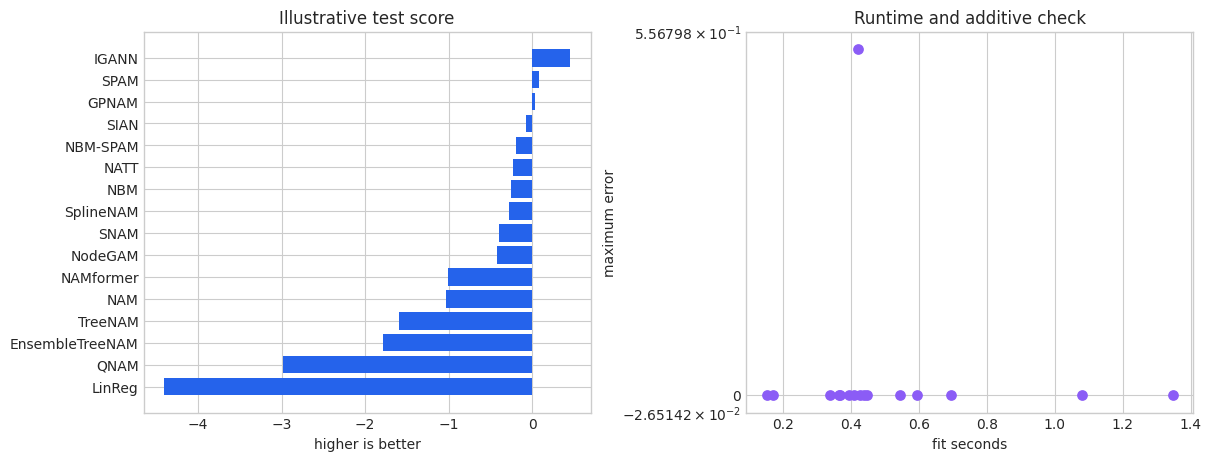

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
plot_data = comparison.sort_values("test score")
axes[0].barh(plot_data["model"], plot_data["test score"], color=COLORS[0])
axes[0].set(title="Illustrative test score", xlabel="higher is better")
axes[1].scatter(comparison["fit seconds"], comparison["reconstruction error"], color=COLORS[3], s=45)
axes[1].set(title="Runtime and additive check", xlabel="fit seconds", ylabel="maximum error", yscale="symlog")
plt.show()
plt.close(fig)
